#Traffic Sign Image Classification Using CNN and Transfer Learning

## 1.Mounting Google Drive and Preparing Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Required Libraries


In [ ]:
import os
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# 2. Data Understanding, Analysis, Visualization and Cleaning

In [ ]:
# Path to zip file in Google Drive
drive_zip_path = "/content/drive/MyDrive/AI and Machine Learning/Traffic Sign Project/Traffic_Sign-20260416T070238Z-3-001.zip"

# Copy zip to Colab working directory
!cp "$drive_zip_path" /content/

print("Zip file copied to /content/")

Zip file copied to /content/


In [ ]:
zip_path = "/content/Traffic_Sign-20260416T070238Z-3-001.zip"
extract_path = "/content/dataset"

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


### 2.1 Dataset Loading and Structure

In [ ]:
# Check extracted folder
print(os.listdir("/content/dataset"))

# Go inside
dataset_main = "/content/dataset/Traffic_Sign"
train_dir = os.path.join(dataset_main, "Train")
test_dir = os.path.join(dataset_main, "Test")

print("\nTrain Classes:", os.listdir(train_dir))
print("Test Folder:", os.listdir(test_dir))

['Traffic_Sign']

Train Classes: ['Caution', 'OverSpeed', 'Instructions', 'No Passing']
Test Folder: ['00028_00000_00007.png', '00003_00000_00001.png', '00009_00001_00027.png', '00018_00000_00001.png']


### 2.2 Dataset Analysis and Class Distribution

In [ ]:
class_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images

print("Image count per class:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

Image count per class:
Caution: 2429
OverSpeed: 5249
Instructions: 2848
No Passing: 5369


### 2.3 Data Cleaning

In [ ]:
#Detect Corrupted Images
from PIL import Image

corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()  # check if corrupted
        except:
            corrupted_images.append(img_path)

print("Total corrupted images found:", len(corrupted_images))

Total corrupted images found: 28


In [ ]:
#Remove Corrupted Images
for img_path in corrupted_images:
    os.remove(img_path)

print("Corrupted images removed.")

Corrupted images removed.


In [ ]:
#Verify if corrupted images are removed or not
print("Remaining corrupted images should be 0")

check_again = 0

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            check_again += 1

print("Corrupted images remaining:", check_again)

Remaining corrupted images should be 0
Corrupted images remaining: 0


### 2.4 Dataset Analysis and Class Distribution

In [ ]:
#Recount images (After Cleaning)
class_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images

print("Updated Image Count per Class:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

Updated Image Count per Class:
Caution: 2422
OverSpeed: 5242
Instructions: 2841
No Passing: 5362


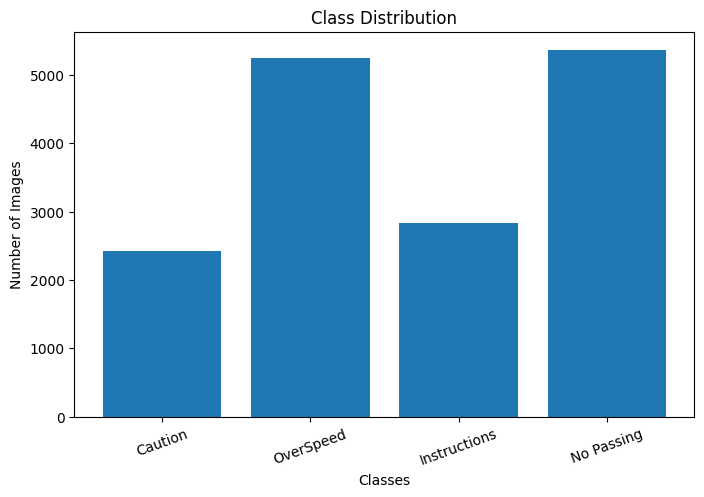

In [ ]:
#Plot Class Distribution
plt.figure(figsize=(8,5))

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

plt.show()

### 2.5 Data Visualization

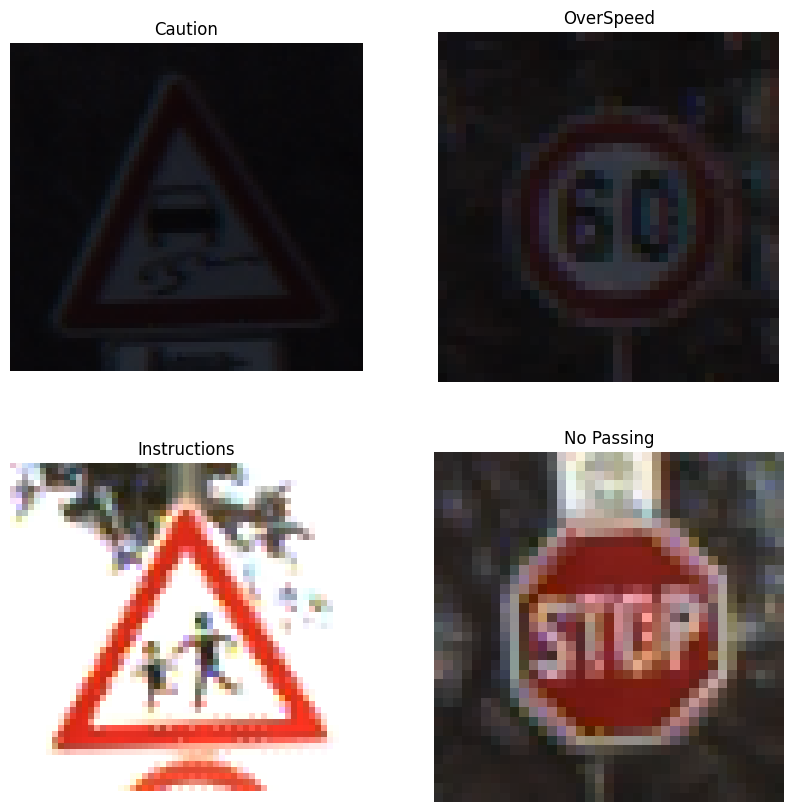

In [ ]:
import random

plt.figure(figsize=(10,10))

i = 1
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2,2,i)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

    i += 1

plt.show()

### 2.6 Data Preprocessing and Splitting

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size and batch
img_size = (224, 224)
batch_size = 32

# Data generator with validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data
val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.


### 2.7 Data Augmentation

Data augmentation was not applied in this project. The dataset contains 15,867 images across four classes which provides sufficient volume for the model to learn from. Applying augmentation techniques such as rotation, flipping or zoom could be explored in future work to further improve generalization, particularly for the minority classes such as Caution and Instructions.

## 3. Designing and Analyzing Convolutional Neural Network (CNN)

### 3.1 Baseline CNN Model Architecture:
The baseline CNN model is designed using a simple architecture consisting of three convolutional layers followed by pooling layers, and three fully connected layers. The model aims to extract spatial features from images and perform multi-class classification.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# Convolutional Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

# Convolutional Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Convolutional Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(4, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,428 (42.65 MB)

 Trainable params: 11,179,428 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Model Compilation

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

The model is compiled using the Adam optimizer, categorical cross-entropy loss function, and accuracy as the evaluation metric. These choices are suitable for multi-class classification problems.

### 3.3 Model Training

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.9419 - loss: 0.1595 - val_accuracy: 0.6012 - val_loss: 2.8053
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.9858 - loss: 0.0467 - val_accuracy: 0.7661 - val_loss: 3.8665
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.9941 - loss: 0.0199 - val_accuracy: 0.7585 - val_loss: 4.9385
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9929 - loss: 0.0238 - val_accuracy: 0.7620 - val_loss: 4.6403
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.9911 - loss: 0.0323 - val_accuracy: 0.7970 - val_loss: 6.8290
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.9962 - loss: 0.0129 - val_accuracy: 0.7989 - val_loss: 3.7110
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.9978 - loss: 0.0074 - val_accuracy: 0.7623 - val_loss: 4.7996
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.9950 - loss: 0.0214 - 

The model was trained for 10 epochs using the training dataset and evaluated on the validation dataset. The training accuracy increased steadily, while the validation accuracy remained lower. Additionally, the validation loss showed fluctuations and remained higher than the training loss. This indicates that the model is overfitting, as it learns the training data well but does not generalize effectively to unseen data.

### 3.4 Training Performance Visualization

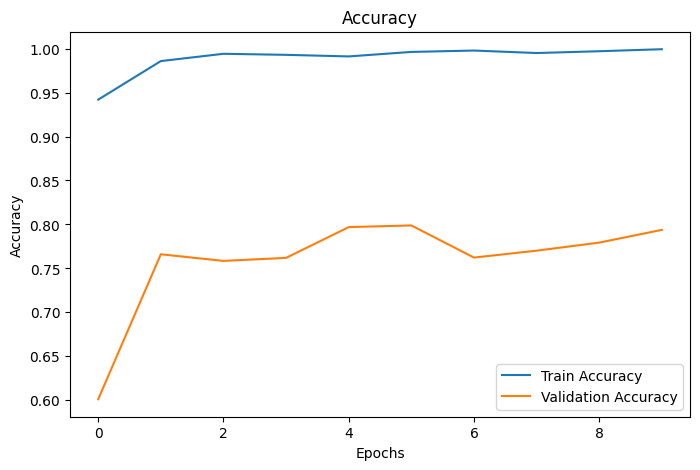

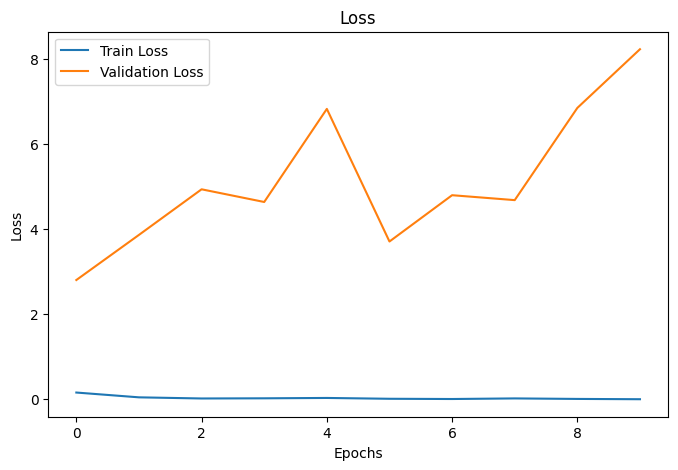

In [ ]:
# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

The training accuracy increases rapidly and reaches nearly 100%, while the validation accuracy remains lower and fluctuates between approximately 70% and 78%. Additionally, the training loss decreases close to zero, whereas the validation loss remains high and unstable throughout the epochs. This behavior clearly indicates overfitting, where the model learns the training data extremely well but fails to generalize effectively to unseen validation data.

### 3.5 Baseline Model Evaluation

Classification Report for Baseline CNN:
              precision    recall  f1-score   support

     Caution       0.47      0.97      0.63       484
Instructions       1.00      0.05      0.10       568
  No Passing       0.98      0.92      0.95      1072
   OverSpeed       0.91      0.98      0.95      1048

    accuracy                           0.79      3172
   macro avg       0.84      0.73      0.66      3172
weighted avg       0.88      0.79      0.75      3172



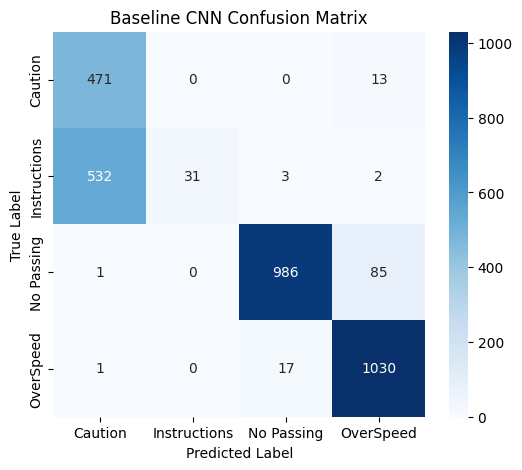

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_generator.reset()

baseline_predictions = model.predict(val_generator, verbose=0)
baseline_pred_classes = np.argmax(baseline_predictions, axis=1)
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print("Classification Report for Baseline CNN:")
print(classification_report(true_classes, baseline_pred_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, baseline_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 3.6 Deeper CNN Model with Regularization

In [ ]:
from tensorflow.keras.layers import BatchNormalization, Dropout
import time

deeper_model = Sequential()

# Block 1
deeper_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
deeper_model.add(BatchNormalization())
deeper_model.add(Conv2D(32, (3,3), activation='relu'))
deeper_model.add(MaxPooling2D(2,2))
deeper_model.add(Dropout(0.25))

# Block 2
deeper_model.add(Conv2D(64, (3,3), activation='relu'))
deeper_model.add(BatchNormalization())
deeper_model.add(Conv2D(64, (3,3), activation='relu'))
deeper_model.add(MaxPooling2D(2,2))
deeper_model.add(Dropout(0.25))

# Block 3
deeper_model.add(Conv2D(128, (3,3), activation='relu'))
deeper_model.add(BatchNormalization())
deeper_model.add(Conv2D(128, (3,3), activation='relu'))
deeper_model.add(MaxPooling2D(2,2))
deeper_model.add(Dropout(0.30))

# Fully connected layers
deeper_model.add(Flatten())
deeper_model.add(Dense(256, activation='relu'))
deeper_model.add(Dropout(0.5))
deeper_model.add(Dense(128, activation='relu'))
deeper_model.add(Dropout(0.5))
deeper_model.add(Dense(64, activation='relu'))

# Output layer
deeper_model.add(Dense(4, activation='softmax'))

deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    18,874,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,203,940 (73.26 MB)

 Trainable params: 19,203,492 (73.26 MB)

 Non-trainable params: 448 (1.75 KB)

A deeper CNN model was developed by increasing the number of convolutional layers compared to the baseline model. Each convolutional block consists of multiple convolutional layers followed by batch normalization and max-pooling operations. Dropout layers were introduced at different stages of the network to reduce overfitting, while batch normalization was used to stabilize and accelerate the training process. This deeper architecture allows the model to learn more complex and hierarchical features from the input images.

### 3.7 Deeper Model Compilation

In [ ]:
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 3.8 Deeper Model Training

In [ ]:
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

end_time = time.time()
deeper_training_time = end_time - start_time

print("Deeper Model Training Time:", deeper_training_time, "seconds")

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 101s 200ms/step - accuracy: 0.4549 - loss: 1.9158 - val_accuracy: 0.3383 - val_loss: 1.5011
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.4820 - loss: 1.0463 - val_accuracy: 0.3398 - val_loss: 1.4357
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 59s 147ms/step - accuracy: 0.5144 - loss: 0.9330 - val_accuracy: 0.3446 - val_loss: 1.5103
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 59s 148ms/step - accuracy: 0.4906 - loss: 1.0163 - val_accuracy: 0.3313 - val_loss: 1.5335
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 146ms/step - accuracy: 0.5006 - loss: 0.9300 - val_accuracy: 0.3474 - val_loss: 1.5861
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.5031 - loss: 0.9172 - val_accuracy: 0.3537 - val_loss: 1.6205
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.5140 - loss: 0.8925 - val_accuracy: 0.3480 - val_loss: 1.6988
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.5527 - loss: 

The deeper CNN model was trained for 10 epochs and evaluated on the validation dataset. The training accuracy gradually increased to around 64%, while the validation accuracy reached approximately 56%. Although there is some improvement across epochs, the validation performance remains lower than training performance, indicating overfitting. The validation loss also fluctuates and remains relatively high. The use of dropout and batch normalization provides some regularization, but the model still struggles to generalize effectively.

### 3.9 Deeper Model Training Performance Visualization

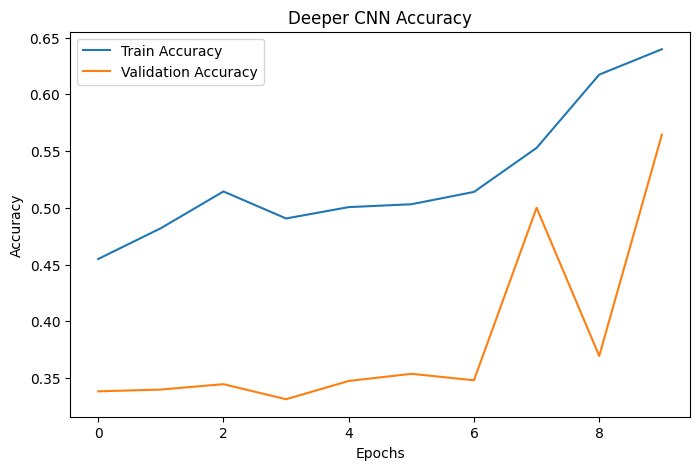

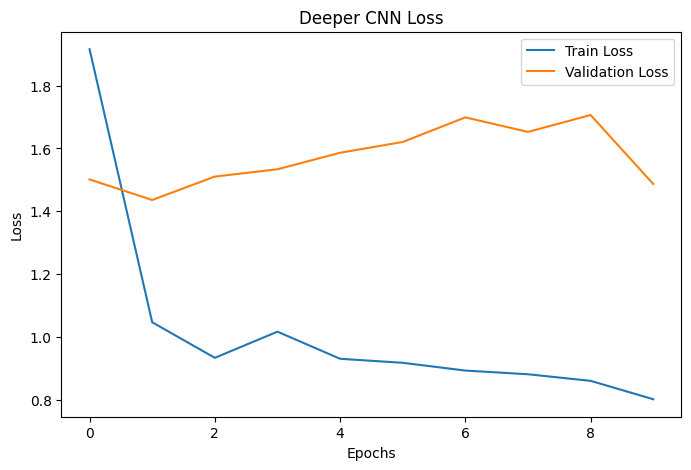

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(deeper_history.history['accuracy'], label='Train Accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Deeper CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(deeper_history.history['loss'], label='Train Loss')
plt.plot(deeper_history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Deeper CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### 3.10 Deeper Model Evaluation

Classification Report for Deeper CNN:
              precision    recall  f1-score   support

     Caution       0.00      0.00      0.00       484
Instructions       0.92      0.06      0.11       568
  No Passing       0.43      0.87      0.58      1072
   OverSpeed       0.86      0.78      0.82      1048

    accuracy                           0.56      3172
   macro avg       0.55      0.43      0.38      3172
weighted avg       0.59      0.56      0.48      3172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


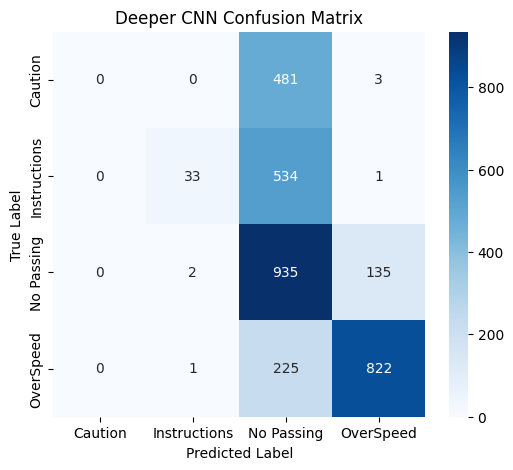

In [ ]:
val_generator.reset()

deeper_predictions = deeper_model.predict(val_generator, verbose=0)
deeper_pred_classes = np.argmax(deeper_predictions, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print("Classification Report for Deeper CNN:")
print(classification_report(true_classes, deeper_pred_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, deeper_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.title("Deeper CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 4. Experimentation and Comparative Analysis

### 4.1 Comparison Between Baseline and Deeper CNN Model
The baseline CNN model shows clear overfitting, with higher training performance compared to validation performance. The deeper CNN model, which includes dropout and batch normalization, shows a modest and inconsistent improvement in validation accuracy. However, validation loss remains high and fluctuating, indicating that overfitting is reduced but not eliminated. This suggests that regularization techniques improve generalization to some extent, but further tuning is required.

### 4.2 Computational Efficiency Analysis
The deeper CNN model required more training time compared to the baseline model due to its increased number of layers and parameters (approximately 19 million vs. 11 million). Although the deeper model provides some improvement in validation performance, it comes at the cost of higher computational complexity and longer training time. This highlights the trade-off between model performance and computational efficiency.

### 4.3 Optimizer Analysis: Adam vs SGD

In [ ]:
#Build SGD Model
sgd_model = Sequential()

# Block 1
sgd_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
sgd_model.add(BatchNormalization())
sgd_model.add(Conv2D(32, (3,3), activation='relu'))
sgd_model.add(MaxPooling2D(2,2))
sgd_model.add(Dropout(0.25))

# Block 2
sgd_model.add(Conv2D(64, (3,3), activation='relu'))
sgd_model.add(BatchNormalization())
sgd_model.add(Conv2D(64, (3,3), activation='relu'))
sgd_model.add(MaxPooling2D(2,2))
sgd_model.add(Dropout(0.25))

# Block 3
sgd_model.add(Conv2D(128, (3,3), activation='relu'))
sgd_model.add(BatchNormalization())
sgd_model.add(Conv2D(128, (3,3), activation='relu'))
sgd_model.add(MaxPooling2D(2,2))
sgd_model.add(Dropout(0.30))

# Fully connected layers
sgd_model.add(Flatten())
sgd_model.add(Dense(256, activation='relu'))
sgd_model.add(Dropout(0.5))
sgd_model.add(Dense(128, activation='relu'))
sgd_model.add(Dropout(0.5))
sgd_model.add(Dense(64, activation='relu'))

# Output layer
sgd_model.add(Dense(4, activation='softmax'))

sgd_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    18,874,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,203,940 (73.26 MB)

 Trainable params: 19,203,492 (73.26 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#Compile with SGD
from tensorflow.keras.optimizers import SGD

sgd_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train SGD Model
start_time = time.time()

sgd_history = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

end_time = time.time()
sgd_training_time = end_time - start_time

print("SGD Model Training Time:", sgd_training_time, "seconds")

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 72s 165ms/step - accuracy: 0.5991 - loss: 0.9807 - val_accuracy: 0.6189 - val_loss: 1.1135
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 146ms/step - accuracy: 0.9372 - loss: 0.1908 - val_accuracy: 0.7226 - val_loss: 2.1149
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 59s 148ms/step - accuracy: 0.9727 - loss: 0.0942 - val_accuracy: 0.6813 - val_loss: 2.7899
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 146ms/step - accuracy: 0.9802 - loss: 0.0681 - val_accuracy: 0.7777 - val_loss: 2.4447
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 146ms/step - accuracy: 0.9868 - loss: 0.0493 - val_accuracy: 0.7289 - val_loss: 3.2587
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 59s 148ms/step - accuracy: 0.9886 - loss: 0.0405 - val_accuracy: 0.7642 - val_loss: 3.4308
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 59s 148ms/step - accuracy: 0.9909 - loss: 0.0313 - val_accuracy: 0.7724 - val_loss: 3.8071
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 147ms/step - accuracy: 0.9914 - loss: 0

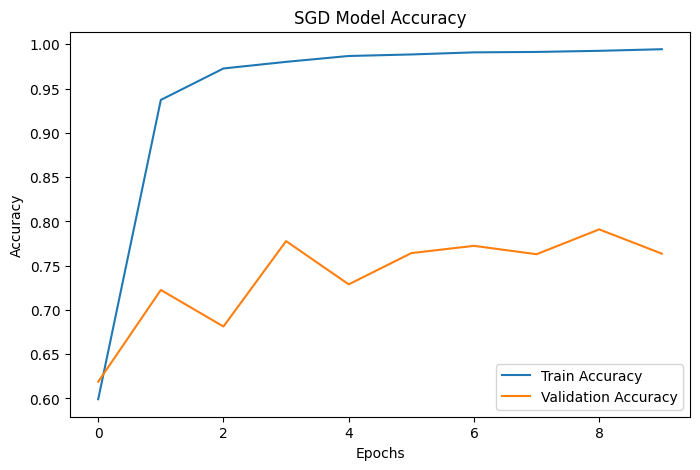

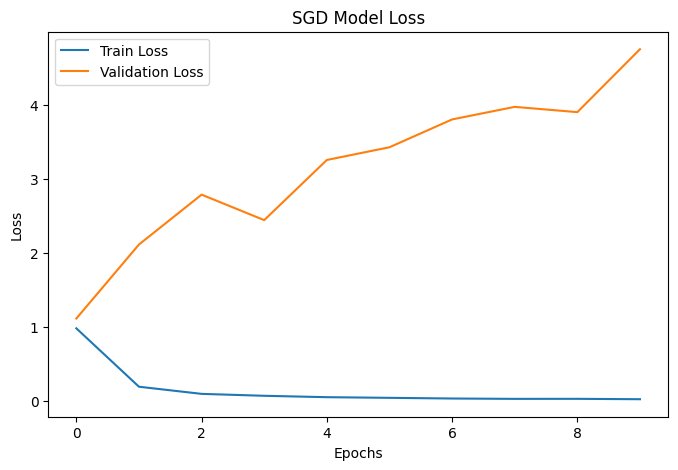

In [ ]:
### SGD Model Training Performance Visualization
plt.figure(figsize=(8,5))
plt.plot(sgd_history.history['accuracy'], label='Train Accuracy')
plt.plot(sgd_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("SGD Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(sgd_history.history['loss'], label='Train Loss')
plt.plot(sgd_history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("SGD Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### 4.3.1 SGD Model Evaluation

Classification Report for SGD Model:
              precision    recall  f1-score   support

     Caution       0.47      0.99      0.64       484
Instructions       1.00      0.06      0.11       568
  No Passing       0.96      0.85      0.90      1072
   OverSpeed       0.86      0.96      0.90      1048

    accuracy                           0.76      3172
   macro avg       0.82      0.71      0.64      3172
weighted avg       0.86      0.76      0.72      3172



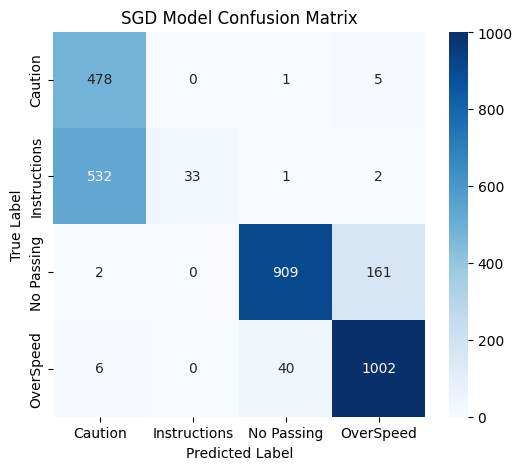

In [ ]:
# SGD Model Evaluation
val_generator.reset()

sgd_predictions = sgd_model.predict(val_generator, verbose=0)
sgd_pred_classes = np.argmax(sgd_predictions, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print("Classification Report for SGD Model:")
print(classification_report(true_classes, sgd_pred_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, sgd_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.title("SGD Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The SGD model evaluation provides a direct comparison with the Adam-trained deeper model. The classification report and confusion matrix show how optimizer choice affects not just convergence speed but also the final per-class precision, recall and F1-score.

The deeper CNN model was trained using both Adam and SGD optimizers to compare their impact on performance. The Adam optimizer achieved faster convergence and slightly higher validation accuracy compared to SGD. In contrast, the SGD optimizer showed more stable training behavior with smoother loss curves but required more epochs to reach similar performance.

While both optimizers achieved comparable training accuracy, Adam performed better in terms of convergence speed and overall efficiency. However, SGD demonstrated more consistent validation loss behavior, indicating more stable learning. This highlights the trade-off between faster convergence (Adam) and training stability (SGD).

### 4.4 Ablation Study: Deeper Model Without Dropout

In this ablation study, dropout layers were removed from the deeper CNN model while keeping the remaining architecture the same. This helps analyze the effect of dropout on model generalization and overfitting.

In [ ]:
#Build model without Dropout
ablation_model = Sequential()

# Block 1
ablation_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
ablation_model.add(BatchNormalization())
ablation_model.add(Conv2D(32, (3,3), activation='relu'))
ablation_model.add(MaxPooling2D(2,2))

# Block 2
ablation_model.add(Conv2D(64, (3,3), activation='relu'))
ablation_model.add(BatchNormalization())
ablation_model.add(Conv2D(64, (3,3), activation='relu'))
ablation_model.add(MaxPooling2D(2,2))

# Block 3
ablation_model.add(Conv2D(128, (3,3), activation='relu'))
ablation_model.add(BatchNormalization())
ablation_model.add(Conv2D(128, (3,3), activation='relu'))
ablation_model.add(MaxPooling2D(2,2))

# Fully connected layers
ablation_model.add(Flatten())
ablation_model.add(Dense(256, activation='relu'))
ablation_model.add(Dense(128, activation='relu'))
ablation_model.add(Dense(64, activation='relu'))

# Output layer
ablation_model.add(Dense(4, activation='softmax'))

ablation_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    18,874,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,203,940 (73.26 MB)

 Trainable params: 19,203,492 (73.26 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#Compile
ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train
start_time = time.time()

ablation_history = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

end_time = time.time()
ablation_training_time = end_time - start_time

print("Ablation Model Training Time:", ablation_training_time, "seconds")

Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 69s 158ms/step - accuracy: 0.9134 - loss: 0.5542 - val_accuracy: 0.4984 - val_loss: 2.2656
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 57s 144ms/step - accuracy: 0.9861 - loss: 0.0589 - val_accuracy: 0.7746 - val_loss: 4.2289
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 57s 145ms/step - accuracy: 0.9931 - loss: 0.0257 - val_accuracy: 0.7339 - val_loss: 3.8867
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.9833 - loss: 0.1162 - val_accuracy: 0.7374 - val_loss: 5.2436
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 147ms/step - accuracy: 0.9883 - loss: 0.0543 - val_accuracy: 0.7721 - val_loss: 5.2494
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 57s 144ms/step - accuracy: 0.9976 - loss: 0.0069 - val_accuracy: 0.7636 - val_loss: 6.2735
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.9976 - loss: 0.0077 - val_accuracy: 0.7677 - val_loss: 6.2156
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.9961 - loss: 0

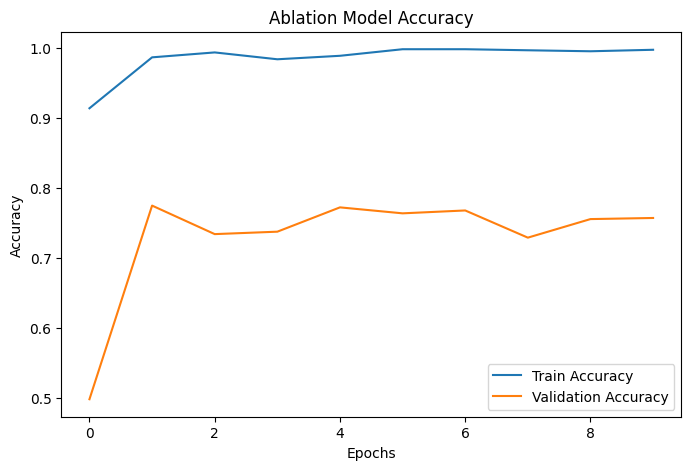

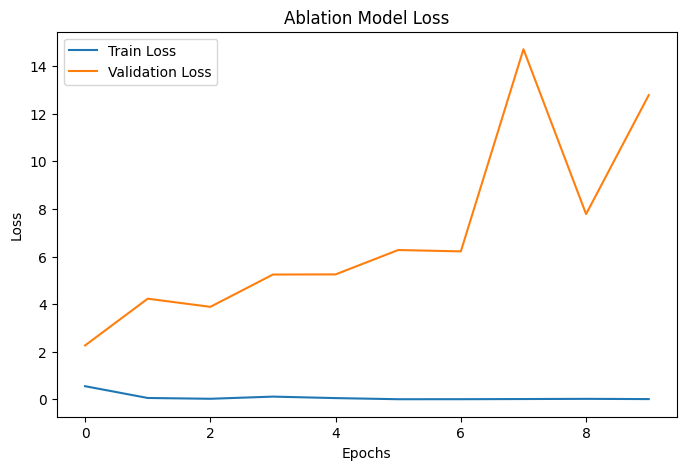

In [ ]:
### Ablation Model Training Performance Visualization
plt.figure(figsize=(8,5))
plt.plot(ablation_history.history['accuracy'], label='Train Accuracy')
plt.plot(ablation_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Ablation Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(ablation_history.history['loss'], label='Train Loss')
plt.plot(ablation_history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Ablation Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### 4.4.1 Ablation Model Evaluation

Classification Report for Ablation Model (No Dropout):
              precision    recall  f1-score   support

     Caution       0.44      0.88      0.59       484
Instructions       0.94      0.05      0.10       568
  No Passing       0.99      0.85      0.91      1072
   OverSpeed       0.83      0.99      0.90      1048

    accuracy                           0.76      3172
   macro avg       0.80      0.69      0.63      3172
weighted avg       0.84      0.76      0.71      3172



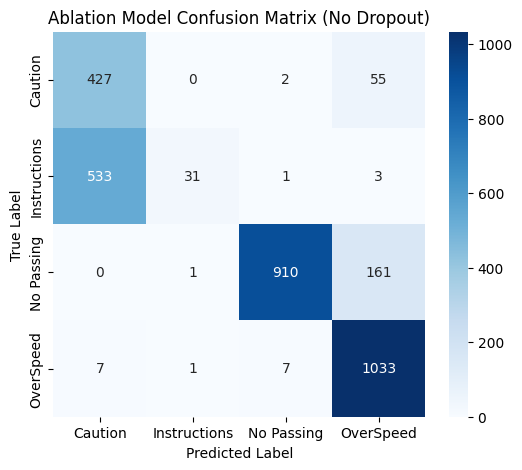

In [ ]:
# Ablation Model Evaluation
val_generator.reset()

ablation_predictions = ablation_model.predict(val_generator, verbose=0)
ablation_pred_classes = np.argmax(ablation_predictions, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print("Classification Report for Ablation Model (No Dropout):")
print(classification_report(true_classes, ablation_pred_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, ablation_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.title("Ablation Model Confusion Matrix (No Dropout)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Comparing the classification report of the ablation model (no dropout) and the deeper model (with dropout) highlights the impact of dropout on per-class performance. A reduction in precision or recall for certain classes suggests that removing dropout negatively affects the model’s ability to generalise to unseen data.

Effect of Removing Dropout

In this ablation study, dropout layers were removed from the deeper CNN model while keeping the rest of the architecture unchanged. The training accuracy remained very high (around 99%), indicating that the model was able to learn the training data effectively.

However, the validation loss became significantly higher and more unstable compared to the model with dropout. Although the validation accuracy remained in a similar range, the large fluctuations in validation loss indicate increased overfitting.

This suggest that dropout plays a crucial role in regularizing the model and improving generalization performance. Without dropout, the model tends to memorize the training data more strongly, leading to poorer performance on unseen validation data.

### 4.5 Challenges and Observations

During the development and training of the CNN models, several challenges were encountered. One of the primary issues observed was overfitting, where the models achieved very high training accuracy but comparatively lower validation accuracy. This indicates that the models were able to learn the training data effectively but struggled to generalize to unseen data.

Another challenge was the instability in validation loss, particularly in deeper models and during the ablation study. Removing dropout resulted in significant fluctuations and higher loss values, highlighting the importance of regularization techniques such as dropout and batch normalization in improving model generalization.

Additionally, increasing model complexity led to longer training times and higher computational cost, demonstrating the trade-off between performance and efficiency.

Overall, these observations emphasize the importance of proper model tuning, regularization, and careful architectural design to achieve better generalization and stable performance.

All experiments were conducted using Google Colab with GPU acceleration to improve training efficiency.

## 5. Transfer Learning Using Pretrained CNN Models

### 5.1 Loading Pretrained Model (MobileNetV2)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # Freeze base model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


A pre-trained MobileNetV2 model was used as the base model. The top classification layers were removed, and the pre-trained weights from ImageNet were utilized. The base model was frozen to prevent its weights from being updated during training.

### 5.2 Adding Custom Classification Layers

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)

output = Dense(4, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

transfer_model.summary()

Model: "functional_72"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,430,468 (9.27 MB)

 Trainable params: 172,484 (673.77 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 5.3 Model Compilation

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 5.4 Model Training (Feature Extraction)

In [ ]:
start_time = time.time()

transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

end_time = time.time()
transfer_time = end_time - start_time

print("Transfer Learning Training Time:", transfer_time, "seconds")

Epoch 1/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 68s 125ms/step - accuracy: 0.9432 - loss: 0.1478 - val_accuracy: 0.7796 - val_loss: 2.8179
Epoch 2/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9823 - loss: 0.0476 - val_accuracy: 0.7954 - val_loss: 3.4215
Epoch 3/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9859 - loss: 0.0370 - val_accuracy: 0.7967 - val_loss: 3.6110
Epoch 4/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9918 - loss: 0.0220 - val_accuracy: 0.7970 - val_loss: 4.5590
Epoch 5/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9925 - loss: 0.0210 - val_accuracy: 0.7881 - val_loss: 4.4831
Transfer Learning Training Time: 168.6190423965454 seconds


### 5.5 Feature Extraction Training Performance Visualization

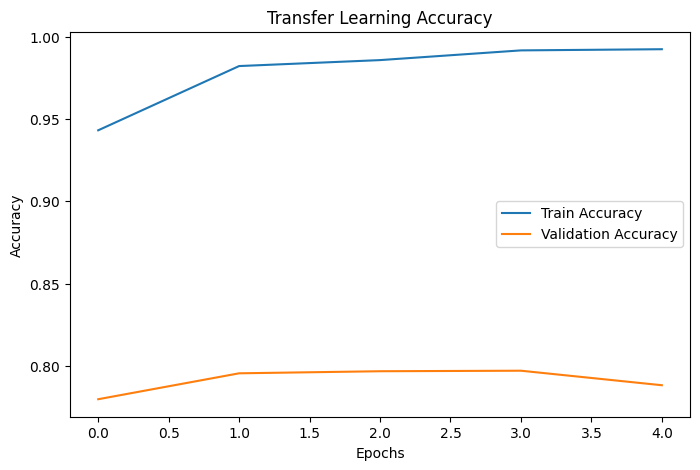

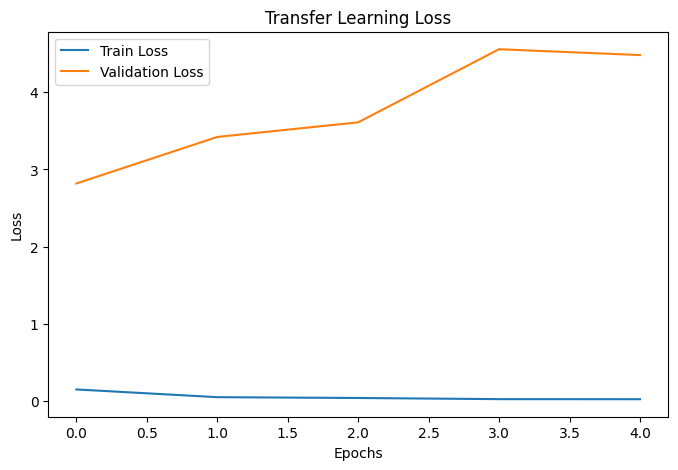

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(transfer_history.history['accuracy'], label='Train Accuracy')
plt.plot(transfer_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Transfer Learning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(transfer_history.history['loss'], label='Train Loss')
plt.plot(transfer_history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Transfer Learning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### 5.6 Transfer Learning Model Evaluation

Classification Report for Transfer Learning Model:
              precision    recall  f1-score   support

     Caution       0.47      0.97      0.63       484
Instructions       0.58      0.06      0.11       568
  No Passing       0.92      0.96      0.94      1072
   OverSpeed       0.97      0.92      0.94      1048

    accuracy                           0.79      3172
   macro avg       0.74      0.73      0.66      3172
weighted avg       0.81      0.79      0.75      3172



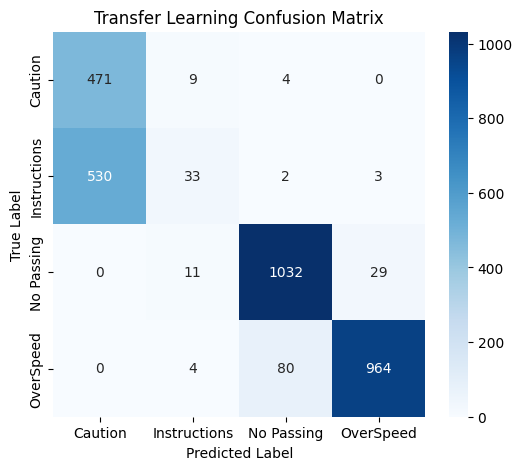

In [ ]:
val_generator.reset()

transfer_predictions = transfer_model.predict(val_generator, verbose=0)
transfer_pred_classes = np.argmax(transfer_predictions, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print("Classification Report for Transfer Learning Model:")
print(classification_report(true_classes, transfer_pred_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, transfer_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 5.7 Fine-Tuning the Model

In [ ]:
# Unfreeze last few layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9512 - loss: 0.1692 - val_accuracy: 0.7834 - val_loss: 4.9608
Epoch 2/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.9826 - loss: 0.0508 - val_accuracy: 0.7699 - val_loss: 5.1703
Epoch 3/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.9891 - loss: 0.0294 - val_accuracy: 0.7888 - val_loss: 4.9573
Epoch 4/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9936 - loss: 0.0193 - val_accuracy: 0.7982 - val_loss: 4.8956
Epoch 5/5
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.9962 - loss: 0.0120 - val_accuracy: 0.7960 - val_loss: 4.7531


In the fine-tuning stage, the last few layers of the pre-trained MobileNetV2 model were unfrozen and retrained along with the custom classification layers. Although the training accuracy remained very high, the validation accuracy showed fluctuations across epochs, and the validation loss remained relatively high.

This indicates that fine-tuning led to overfitting and degraded generalization performance. A possible reason is that updating pre-trained weights, even with a small learning rate, can still disrupt the learned feature representations, especially when the dataset is limited.

In this experiment, feature extraction proved to be more effective and stable than fine-tuning for the given dataset.

### 5.8 Fine-Tuned Model Evaluation

Classification Report for Fine-Tuned Transfer Learning Model:
              precision    recall  f1-score   support

     Caution       0.47      0.98      0.63       484
Instructions       0.56      0.06      0.11       568
  No Passing       0.97      0.94      0.95      1072
   OverSpeed       0.96      0.97      0.96      1048

    accuracy                           0.80      3172
   macro avg       0.74      0.74      0.66      3172
weighted avg       0.81      0.80      0.76      3172



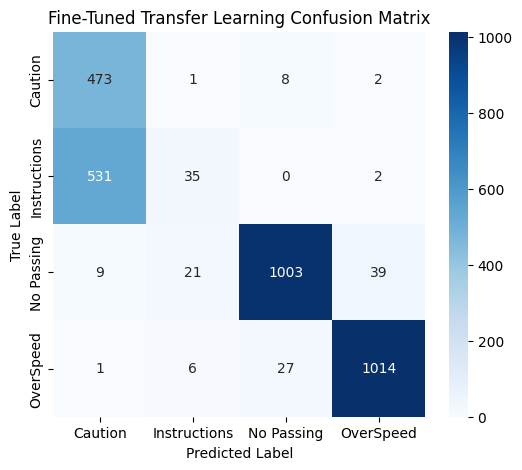

In [ ]:
val_generator.reset()

fine_tuned_predictions = transfer_model.predict(val_generator, verbose=0)
fine_tuned_pred_classes = np.argmax(fine_tuned_predictions, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print("Classification Report for Fine-Tuned Transfer Learning Model:")
print(classification_report(true_classes, fine_tuned_pred_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, fine_tuned_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.title("Fine-Tuned Transfer Learning Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 5.9 Comparison Between CNN and Transfer Learning Models

The transfer learning model using MobileNetV2 outperformed the CNN models trained from scratch in terms of validation accuracy and training efficiency. The feature extraction approach achieved higher validation accuracy (~79%) compared to both the baseline and deeper CNN models.

Additionally, the transfer learning model required significantly less training time (approximately 154 seconds) compared to the CNN models (approximately 700 seconds), demonstrating improved computational efficiency.

However, fine-tuning the pre-trained model led to unstable validation performance and increased overfitting, indicating that feature extraction was more effective for this dataset. Overall, transfer learning proved to be a more efficient and effective approach compared to training CNN models from scratch.

### 5.10 Prediction on Sample Images

Found 3172 images belonging to 4 classes.


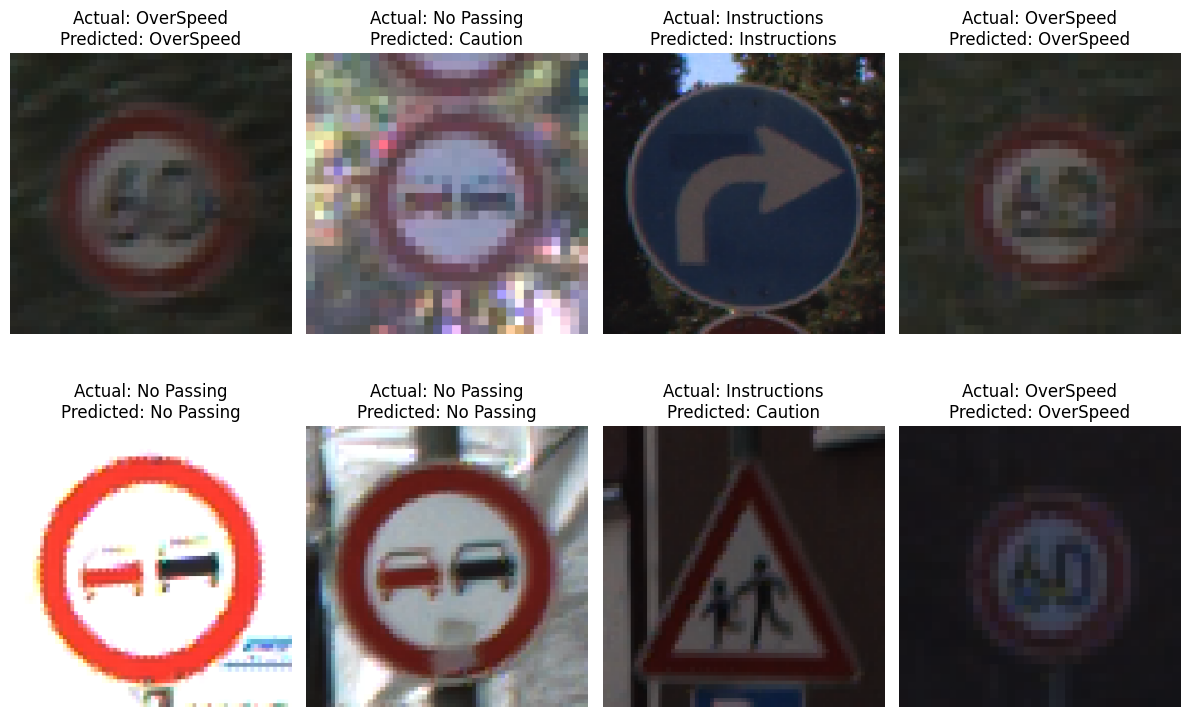

In [ ]:
# Create a shuffled generator ONLY for visualization
sample_generator = datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

images, labels = next(sample_generator)
predictions = transfer_model.predict(images, verbose=0)

actual_classes = np.argmax(labels, axis=1)
predicted_classes = np.argmax(predictions, axis=1)

class_names = list(sample_generator.class_indices.keys())

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title(
        f"Actual: {class_names[actual_classes[i]]}\n"
        f"Predicted: {class_names[predicted_classes[i]]}"
    )

plt.tight_layout()
plt.show()

The sample predictions demonstrate that the transfer learning model is able to correctly classify most traffic sign images across different classes. However, a few misclassifications are observed, particularly between visually similar classes such as "Instructions" and "Caution". This indicates that while the model performs well overall, there is still some ambiguity in distinguishing similar traffic signs.